In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, Flatten, concatenate, Dropout, Multiply, Lambda
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pickle
import os
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, auc, accuracy_score)
from scipy.stats import ttest_rel
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, LSTM, Conv1D, Flatten, concatenate, Dropout,
                                     Multiply, Reshape, BatchNormalization, GlobalAveragePooling1D,
                                     Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
import pandas as pd
import numpy as np
import os
# Save df_final as a .csv file
os.chdir(r'D:\sample_dataset')
df_augmented_data=pd.read_csv('augmented_dataset.csv', low_memory=False)

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, Flatten, concatenate, Dropout, Multiply, Reshape, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Separate the target column ('Label') and features
X = df_augmented_data.drop('Label', axis=1).values  # Features (all columns except the target 'Label')
y = df_augmented_data['Label'].values  # Target column ('Label')

# Normalize the numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
selected_features=[ 0 , 1,  2,  3,  4,  5,  8,  9, 10, 15, 16, 17, 18, 20]

In [8]:
# Convert indices in selected_features to column names
selected_feature_names = df_augmented_data.columns[selected_features]
selected_feature_names

Index(['frame.time', 'frame.time_epoch', 'frame.time_delta',
       'frame.time_delta_displayed', 'frame.time_relative', 'frame.len',
       'ip.hdr_len', 'ip.dsfield.dscp', 'ip.dsfield.ecn', 'ip.flags.df',
       'ip.flags.mf', 'ip.ttl', 'ip.src', 'ip.dst'],
      dtype='object')

In [9]:
# Count the number of attack and normal instances in the 'Label' column
label_counts = df_augmented_data['Label'].value_counts()

# Display the result
print(label_counts)

0    1372539
2      62383
3      17502
8      17159
5       8980
1       8046
6       7458
9       3762
7       3663
4       2508
Name: Label, dtype: int64


In [10]:
# Convert indices in selected_features to column names
selected_feature_names = df_augmented_data.columns[selected_features]

# Select the features and labels using the column names
X = df_augmented_data[selected_feature_names].values
y = df_augmented_data['Label'].values  

In [11]:
# Encode the labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded = pd.get_dummies(y_encoded).values  # One-hot encode for multiclass classification


In [12]:
# Define CNN Model
def create_cnn_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)  # Output layer for multiclass classification
    model = Model(inputs, output)
    return model
# Define LSTM Model
def create_lstm_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = LSTM(64, return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = LSTM(32)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)  # Output layer for multiclass classification
    model = Model(inputs, output)
    return model
# Define FNN Model
def create_fnn_model(input_shape, num_classes):
    inputs = Input(shape=(input_shape,))
    x = Dense(128, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)  # Output layer for multiclass classification
    model = Model(inputs, output)
    return model
# Define attention mechanism
def attention_mechanism(inputs):
    attention_weights = Dense(inputs.shape[-1], activation='softmax', name='attention_weights')(inputs)
    attention_output = Multiply(name='attention_output')([inputs, attention_weights])
    return attention_output, attention_weights



In [13]:
from memory_profiler import memory_usage

In [14]:
def train_ensemble():
    return ensemble_model.fit(
        [X_train_cnn, X_train_cnn, X_train], y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.1,
        verbose=0,
        validation_data=([X_test_cnn, X_test_cnn, X_test], y_test)
    )

In [15]:
# Convert one-hot labels back to class labels for StratifiedKFold
y_labels = np.argmax(y_encoded, axis=1)
# --------------------------------- Part 4: 5-Fold Cross-Validation Setup ---------------------------------
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ensemble_accs, cnn_accs, lstm_accs, fnn_accs = [], [], [], []
ensemble_times, cnn_times, lstm_times, fnn_times = [], [], [], []
ensemble_memory_usages, cnn_memory_usages, lstm_memory_usages, fnn_memory_usages = [], [], [], []
all_y_test = []
all_ensemble_pred = []
all_cnn_pred=[]
all_lstm_pred=[]
all_fnn_pred=[]
all_ensemble_prob = []
all_cm_ensemble = []
all_cm_cnn = []
all_cm_lstm = []
all_cm_fnn = []
attention_weights=[]
avg_atts=[]
fold = 1
for train_idx, test_idx in kfold.split(X, y_labels):
    print(f"\n=== Fold {fold} ===")
    fold += 1

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    # Number of classes in the dataset
    num_classes = y_train.shape[1]
    # CNN
    cnn_model = create_cnn_model(X_train_cnn.shape[1:], num_classes)
    cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    cnn_mem_usage, cnn_history = memory_usage(
    (cnn_model.fit, (X_train_cnn, y_train), {'epochs': 50, 'batch_size': 64, 'validation_split': 0.1, 'verbose': 0}),
    interval=0.1,
    retval=True )
    #cnn_history = cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=0)
    end = time.time()
    cnn_times.append(end - start)
    cnn_peak_memory = max(cnn_mem_usage)
    cnn_memory_usages.append(cnn_peak_memory)
    cnn_pred = (cnn_model.predict(X_test_cnn,verbose=0) > 0.5).astype(int)
    cnn_accs.append(accuracy_score(y_test, cnn_pred))
    
    # LSTM
  
    lstm_model = create_lstm_model(X_train_cnn.shape[1:], num_classes)
    lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    lstm_mem_usage, lstm_history = memory_usage(
    (lstm_model.fit, (X_train_cnn, y_train), {'epochs': 50, 'batch_size': 64, 'validation_split': 0.1, 'verbose': 0}),
     interval=0.1,retval=True)
    #lstm_history= lstm_model.fit(X_train_cnn, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=0)
    end = time.time()
    lstm_times.append(end - start)
    lstm_peak_memory = max(lstm_mem_usage)
    lstm_memory_usages.append(lstm_peak_memory)
    lstm_pred = (lstm_model.predict(X_test_cnn,verbose=0) > 0.5).astype(int)
    lstm_accs.append(accuracy_score(y_test, lstm_pred))
    
     # FNN
    
    fnn_model = create_fnn_model(X_train.shape[1], num_classes)
    fnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    fnn_mem_usage, fnn_history = memory_usage(
    (fnn_model.fit, (X_train, y_train), {'epochs': 50, 'batch_size': 64, 'validation_split': 0.1, 'verbose': 0}),
    interval=0.1,
    retval=True)
    #fnn_history=fnn_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=0)
    end = time.time()
    fnn_times.append(end - start)
    fnn_peak_memory = max(fnn_mem_usage)
    fnn_memory_usages.append(fnn_peak_memory)
    fnn_pred = (fnn_model.predict(X_test,verbose=0) > 0.5).astype(int)
    fnn_accs.append(accuracy_score(y_test, fnn_pred))
    
     # Ensemble
   
    # Get validation accuracy for dynamic weighting
    cnn_val_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)[1]
    lstm_val_accuracy = lstm_model.evaluate(X_test_cnn, y_test, verbose=0)[1]
    fnn_val_accuracy = fnn_model.evaluate(X_test, y_test, verbose=0)[1]
    
    # Calculate dynamic weights based on validation accuracy
    total_accuracy = cnn_val_accuracy + lstm_val_accuracy + fnn_val_accuracy
    weights = {
    'cnn': cnn_val_accuracy / total_accuracy,
    'lstm': lstm_val_accuracy / total_accuracy,
    'fnn': fnn_val_accuracy / total_accuracy
    }
    # Weighted outputs using Lambda layers
    cnn_weighted_output = Lambda(lambda x: x * weights['cnn'])(cnn_model.output)
    lstm_weighted_output = Lambda(lambda x: x * weights['lstm'])(lstm_model.output)
    fnn_weighted_output = Lambda(lambda x: x * weights['fnn'])(fnn_model.output)
    # Combine weighted outputs
    combined = concatenate([cnn_weighted_output, lstm_weighted_output, fnn_weighted_output], name='combined_features')
    # Apply attention mechanism on combined output
    attention_output, attention_tensor = attention_mechanism(combined)
    # Final output layer for multiclass classification
    output = Dense(num_classes, activation='softmax', name='output_layer')(attention_output)
    
    # Directly combine the model outputs without attention for testing
    combined = concatenate([cnn_weighted_output, lstm_weighted_output, fnn_weighted_output], name='combined_features')



   # Define the complete ensemble model
    ensemble_model = Model(inputs=[cnn_model.input, lstm_model.input, fnn_model.input], outputs=output)
    # This returns both the final classification output and attention weights
    ensemble_model_full = Model(inputs=[cnn_model.input, lstm_model.input, fnn_model.input],
                            outputs=[output, attention_tensor])

    # Compile and train the simplified model
    ensemble_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    ensemble_mem_usage, ensemble_history = memory_usage(
    train_ensemble,interval=0.1,retval=True)
    #ensemble_history=ensemble_model.fit(
     #   [X_train_cnn, X_train_cnn, X_train], y_train,
       # validation_data=([X_test_cnn, X_test_cnn, X_test], y_test),
        #epochs=50, batch_size=128, verbose=0)
    ensemble_peak_memory = max(ensemble_mem_usage)
    ensemble_memory_usages.append(ensemble_peak_memory)
    end = time.time()
    ensemble_times.append(end - start)
    ensemble_output, att_weights = ensemble_model_full.predict([X_test_cnn, X_test_cnn, X_test], verbose=0)
    ensemble_pred = (ensemble_output > 0.5).astype(int)
   #ensemble_pred = (ensemble_model.predict([X_test_cnn, X_test_cnn, X_test],verbose=0) > 0.5).astype(int)
    ensemble_accs.append(accuracy_score(y_test, ensemble_pred))
    all_y_test.append(y_test)
    all_ensemble_pred.append(ensemble_pred)
    all_ensemble_prob.append(ensemble_model.predict([X_test_cnn, X_test_cnn, X_test],verbose=0))  # Probabilities for ROC/PR
    ensemble_probs, att_weights = ensemble_model_full.predict([X_test_cnn, X_test_cnn, X_test], verbose=0)
    attention_weights.append(att_weights)  # Now att_weights is a real NumPy array
    avg_atts.append(np.mean(att_weights, axis=0))  # Mean over all test samples
    y_pred_ensemble = ensemble_model.predict([X_test_cnn, X_test_cnn, X_test],verbose=0)
    y_pred_classes_ensemble = np.argmax(y_pred_ensemble, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    cm_ensemble = confusion_matrix(y_true_classes, y_pred_classes_ensemble)
    all_cm_ensemble.append(cm_ensemble)
    y_pred_classes_cnn = np.argmax(cnn_pred, axis=1)
    cm_cnn=confusion_matrix(y_true_classes,  y_pred_classes_cnn)
    all_cm_cnn.append(cm_cnn)
    y_pred_classes_lstm = np.argmax(lstm_pred, axis=1)
    cm_lstm=confusion_matrix(y_true_classes,y_pred_classes_lstm)
    all_cm_lstm.append(cm_lstm)
    y_pred_classes_fnn = np.argmax(fnn_pred, axis=1)
    cm_fnn=confusion_matrix(y_true_classes,  y_pred_classes_fnn)
    all_cm_fnn.append(cm_fnn)
    


=== Fold 1 ===


=== Fold 2 ===

=== Fold 3 ===

=== Fold 4 ===

=== Fold 5 ===


In [20]:
# --------------------------------- Part 5: Report Results ---------------------------------
def report_scores(name, scores, times, memories):
    print(f"{name}: Accuracy = {np.mean(scores):.4f} ± {np.std(scores):.4f}, "
          f"Time = {np.mean(times):.2f}s ± {np.std(times):.2f}s, "
          f"Memory = {np.mean(memories):.2f} MiB ± {np.std(memories):.2f} MiB")

print("\n=== 5-Fold Cross-validation Results ===")
report_scores("CNN", cnn_accs, cnn_times, cnn_memory_usages)
report_scores("LSTM", lstm_accs, lstm_times, lstm_memory_usages)
report_scores("FNN", fnn_accs, fnn_times, fnn_memory_usages)
report_scores("Ensemble", ensemble_accs, ensemble_times, ensemble_memory_usages)


=== 5-Fold Cross-validation Results ===
CNN: Accuracy = 0.9332 ± 0.0027, Time = 497.34s ± 145.28s, Memory = 1488.62 MiB ± 170.04 MiB
LSTM: Accuracy = 0.9424 ± 0.0123, Time = 2600.65s ± 1077.18s, Memory = 1500.22 MiB ± 145.61 MiB
FNN: Accuracy = 0.9126 ± 0.0000, Time = 288.00s ± 113.86s, Memory = 1317.63 MiB ± 111.91 MiB
Ensemble: Accuracy = 0.9800 ± 0.0096, Time = 2039.61s ± 234.18s, Memory = 1488.80 MiB ± 140.32 MiB


In [21]:

# --------------------------------- Part 6: Statistical Significance Testing ---------------------------------
print("\n=== Paired t-tests ===")
print("Ensemble vs CNN:", ttest_rel(ensemble_accs, cnn_accs))
print("Ensemble vs LSTM:", ttest_rel(ensemble_accs, lstm_accs))
print("Ensemble vs FNN:", ttest_rel(ensemble_accs, fnn_accs))


=== Paired t-tests ===
Ensemble vs CNN: TtestResult(statistic=7.852240113549909, pvalue=0.0014210846958986809, df=4)
Ensemble vs LSTM: TtestResult(statistic=4.5188955914851805, pvalue=0.010667313739832018, df=4)
Ensemble vs FNN: TtestResult(statistic=13.997412174613357, pvalue=0.00015112124409402602, df=4)


In [22]:
# Step 1: Define class labels
class_names =  [
    'Normal','fuzzing', 'http-flood', 'http-loris', 'http-smuggle', 'http2-concurrent','http2-pause','quic-enc','quic-flood', 
      'quic-loris'
]
xticklabels=class_names
yticklabels=class_names

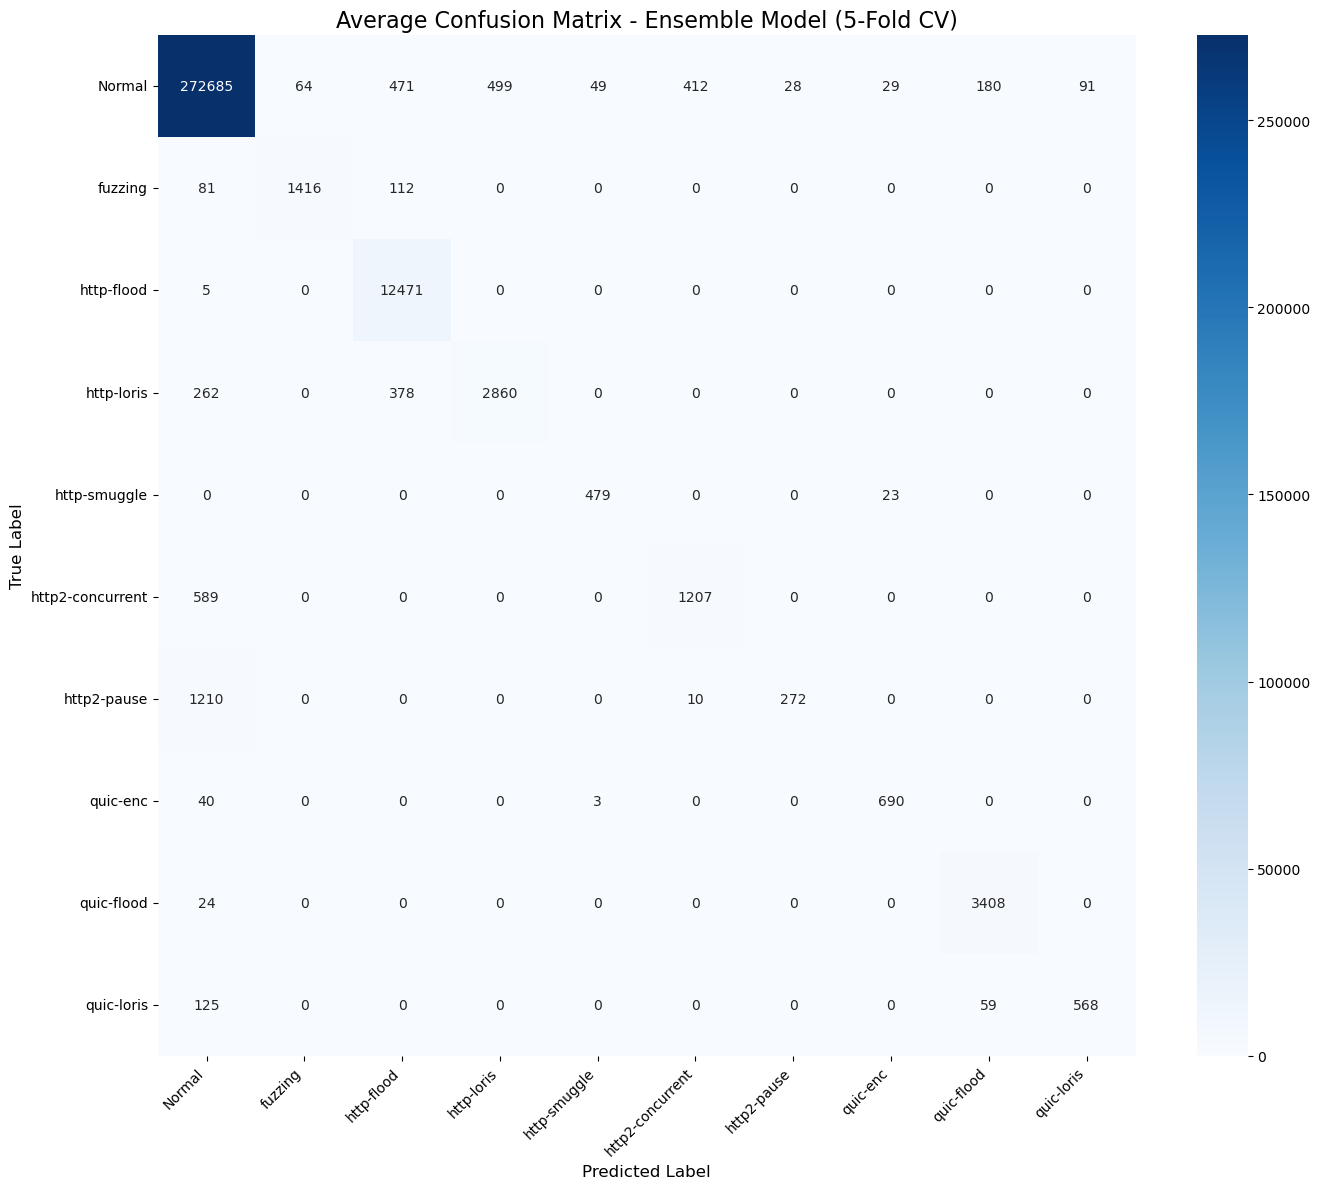

In [25]:
# Step 2: Compute average confusion matrix
avg_cm_ensemble = np.mean(all_cm_ensemble, axis=0).astype(int)

# Step 3: Plot using seaborn
plt.figure(figsize=(14, 12))
sns.heatmap(avg_cm_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Average Confusion Matrix - Ensemble Model (5-Fold CV)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('Peerj_revision1_H23Q_multiclass_confusion_matrix.pdf',format='pdf')
plt.show()


In [29]:
# Step 2: Print classification report of Ensemble model
report = classification_report(y_true_classes , y_pred_classes_ensemble, target_names=class_names)
print("Classification Report - Ensemble Model (5-Fold CV):H23Q-Multiclass Classification")
print(report)


Classification Report - Ensemble Model (5-Fold CV):H23Q-Multiclass Classification
                  precision    recall  f1-score   support

          Normal       0.99      0.99      0.99   1372540
         fuzzing       0.96      0.88      0.92      8045
      http-flood       0.93      1.00      0.96     62380
      http-loris       0.85      0.82      0.83     17500
    http-smuggle       0.90      0.95      0.93      2510
http2-concurrent       0.74      0.67      0.70      8980
     http2-pause       0.91      0.18      0.30      7460
        quic-enc       0.93      0.94      0.94      3665
      quic-flood       0.93      0.99      0.96     17160
      quic-loris       0.86      0.76      0.81      3760

        accuracy                           0.98   1504000
       macro avg       0.90      0.82      0.83   1504000
    weighted avg       0.98      0.98      0.98   1504000



In [31]:
import warnings
warnings.filterwarnings("ignore")

In [33]:
# Step 2: Print classification report

report = classification_report(y_true_classes , y_pred_classes_cnn, target_names=class_names)
print("Classification Report - CNN Model (5-Fold CV):H23Q-Multiclass Classification")
print(report)


Classification Report - CNN Model (5-Fold CV):H23Q-Multiclass Classification
                  precision    recall  f1-score   support

          Normal       0.96      0.98      0.97    274507
         fuzzing       0.87      0.33      0.48      1609
      http-flood       0.67      0.94      0.78     12477
      http-loris       0.42      0.26      0.32      3501
    http-smuggle       0.00      0.00      0.00       502
http2-concurrent       0.00      0.00      0.00      1796
     http2-pause       0.00      0.00      0.00      1492
        quic-enc       0.69      0.06      0.10       732
      quic-flood       0.73      0.08      0.14      3431
      quic-loris       0.00      0.00      0.00       753

        accuracy                           0.94    300800
       macro avg       0.44      0.26      0.28    300800
    weighted avg       0.92      0.94      0.92    300800



In [34]:
# Step 2: Print classification report
report = classification_report(y_true_classes , y_pred_classes_lstm, target_names=class_names)
print("Classification Report - LSTM Model (5-Fold CV):H23Q-Multiclass Classification")
print(report)

Classification Report - LSTM Model (5-Fold CV):H23Q-Multiclass Classification
                  precision    recall  f1-score   support

          Normal       0.97      0.99      0.98    274507
         fuzzing       0.93      0.70      0.80      1609
      http-flood       0.65      0.82      0.73     12477
      http-loris       0.77      0.08      0.14      3501
    http-smuggle       0.96      0.20      0.33       502
http2-concurrent       0.47      0.87      0.61      1796
     http2-pause       0.00      0.00      0.00      1492
        quic-enc       0.76      0.40      0.52       732
      quic-flood       0.86      0.23      0.37      3431
      quic-loris       0.49      0.03      0.05       753

        accuracy                           0.95    300800
       macro avg       0.69      0.43      0.45    300800
    weighted avg       0.95      0.95      0.94    300800



In [35]:
# Step 2: Print classification report
report = classification_report(y_true_classes , y_pred_classes_fnn, target_names=class_names)
print("Classification Report - FNN Model (5-Fold CV):H23Q-Multiclass Classification")
print(report)

Classification Report - FNN Model (5-Fold CV):H23Q-Multiclass Classification
                  precision    recall  f1-score   support

          Normal       0.91      1.00      0.95    274507
         fuzzing       0.00      0.00      0.00      1609
      http-flood       0.00      0.00      0.00     12477
      http-loris       0.00      0.00      0.00      3501
    http-smuggle       0.00      0.00      0.00       502
http2-concurrent       0.00      0.00      0.00      1796
     http2-pause       0.00      0.00      0.00      1492
        quic-enc       0.00      0.00      0.00       732
      quic-flood       0.00      0.00      0.00      3431
      quic-loris       0.00      0.00      0.00       753

        accuracy                           0.91    300800
       macro avg       0.09      0.10      0.10    300800
    weighted avg       0.83      0.91      0.87    300800



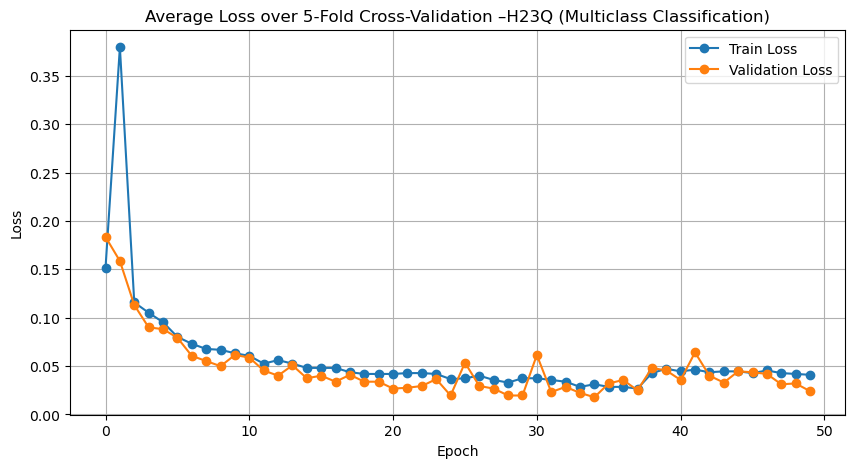

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(ensemble_history.history['loss'], label='Train Loss', marker='o')
plt.plot(ensemble_history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Average Loss over 5-Fold Cross-Validation –H23Q (Multiclass Classification)')
plt.grid(True)
plt.savefig("peerj_revision1_H23Q_loss_multiclass.pdf",format='pdf')
plt.show()

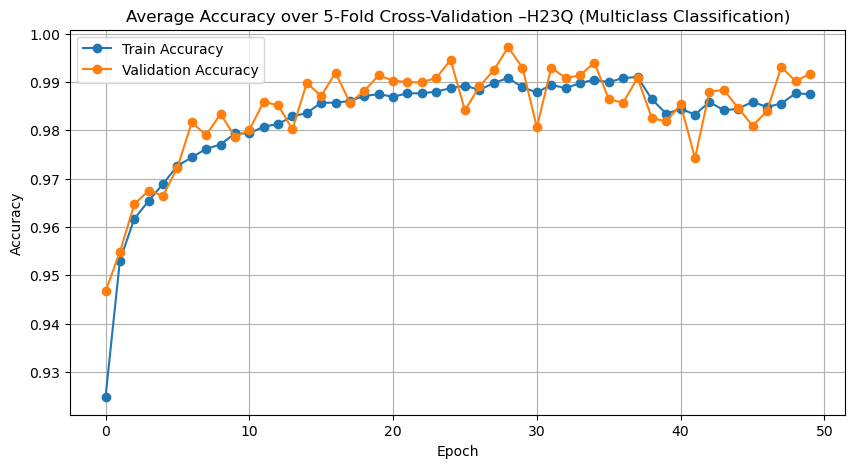

In [47]:
# Accuracy and loss plots
plt.figure(figsize=(10, 5))
plt.plot(ensemble_history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(ensemble_history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Average Accuracy over 5-Fold Cross-Validation –H23Q (Multiclass Classification)')
plt.grid(True)
plt.savefig("peerj_revision1_H23Q_Accuracy_multiclass.pdf",format="pdf")
plt.show()

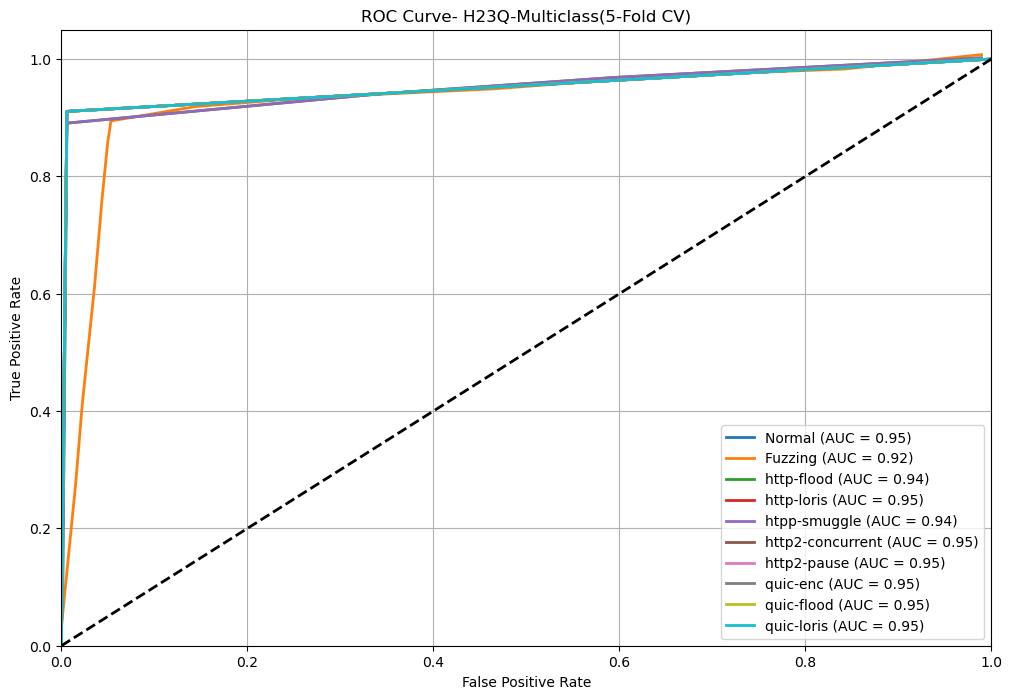

In [55]:
from sklearn.metrics import roc_curve, auc
# Concatenate across folds
y_true_all = np.concatenate(all_y_test, axis=0)
y_scores_all = np.concatenate(all_ensemble_prob, axis=0)
n_classes = y_true_all.shape[1]

#Plot ROC curve per class
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_all[:, i], y_scores_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC={roc_auc:.2f})')

    
  # Plot settings
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve- H23Q-Multiclass(5-Fold CV)')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("Peerj_revision1_ROC_Curve_H23Q_Multiclass.pdf",format='pdf')
plt.show()

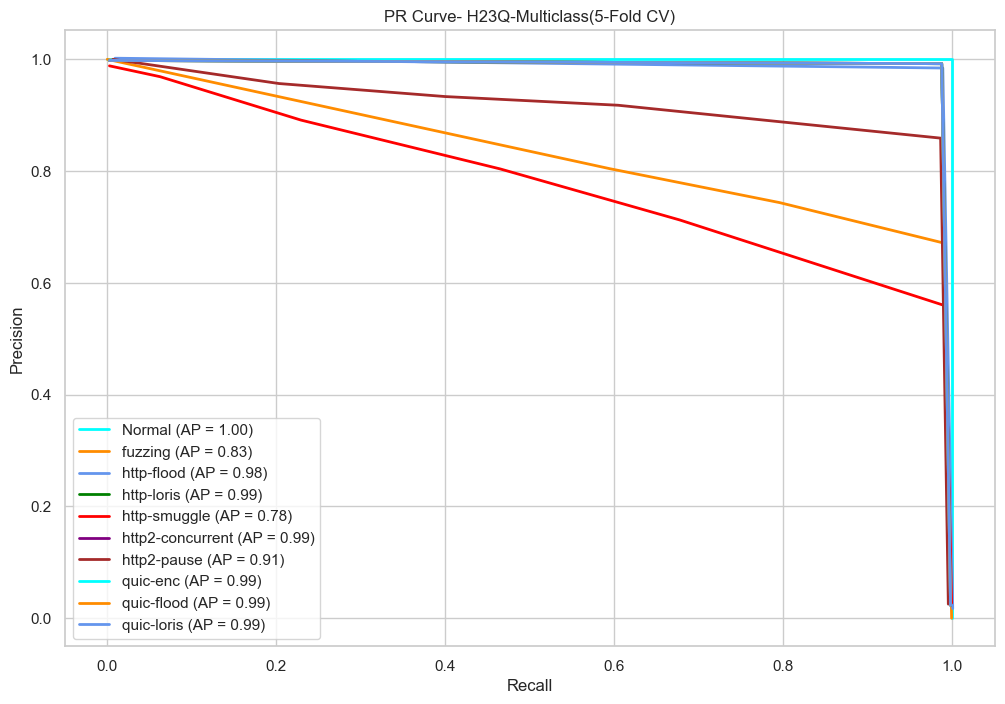

In [66]:
# Concatenate predictions and true labels across folds
y_true_all = np.concatenate(all_y_test, axis=0)
y_scores_all = np.concatenate(all_ensemble_prob, axis=0)

# Number of classes
n_classes = y_true_all.shape[1]

# Plot PR curve per class
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_all[:, i], y_scores_all[:, i])
    ap = average_precision_score(y_true_all[:, i], y_scores_all[:, i])
    plt.plot(recall, precision, lw=2, label=f'{class_names[i]} (AP={ap:.2f})')

# Final plot formatting
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - H23Q-Multiclass(5-Fold CV)')
plt.legend(loc='lower left')
plt.grid(True)
plt.savefig("Peerj_revision1_PR_Curve_H23Q_Multiclass.pdf",format="pdf")
plt.show()


In [56]:

selected_feature_number = np.array([selected_feature_names])

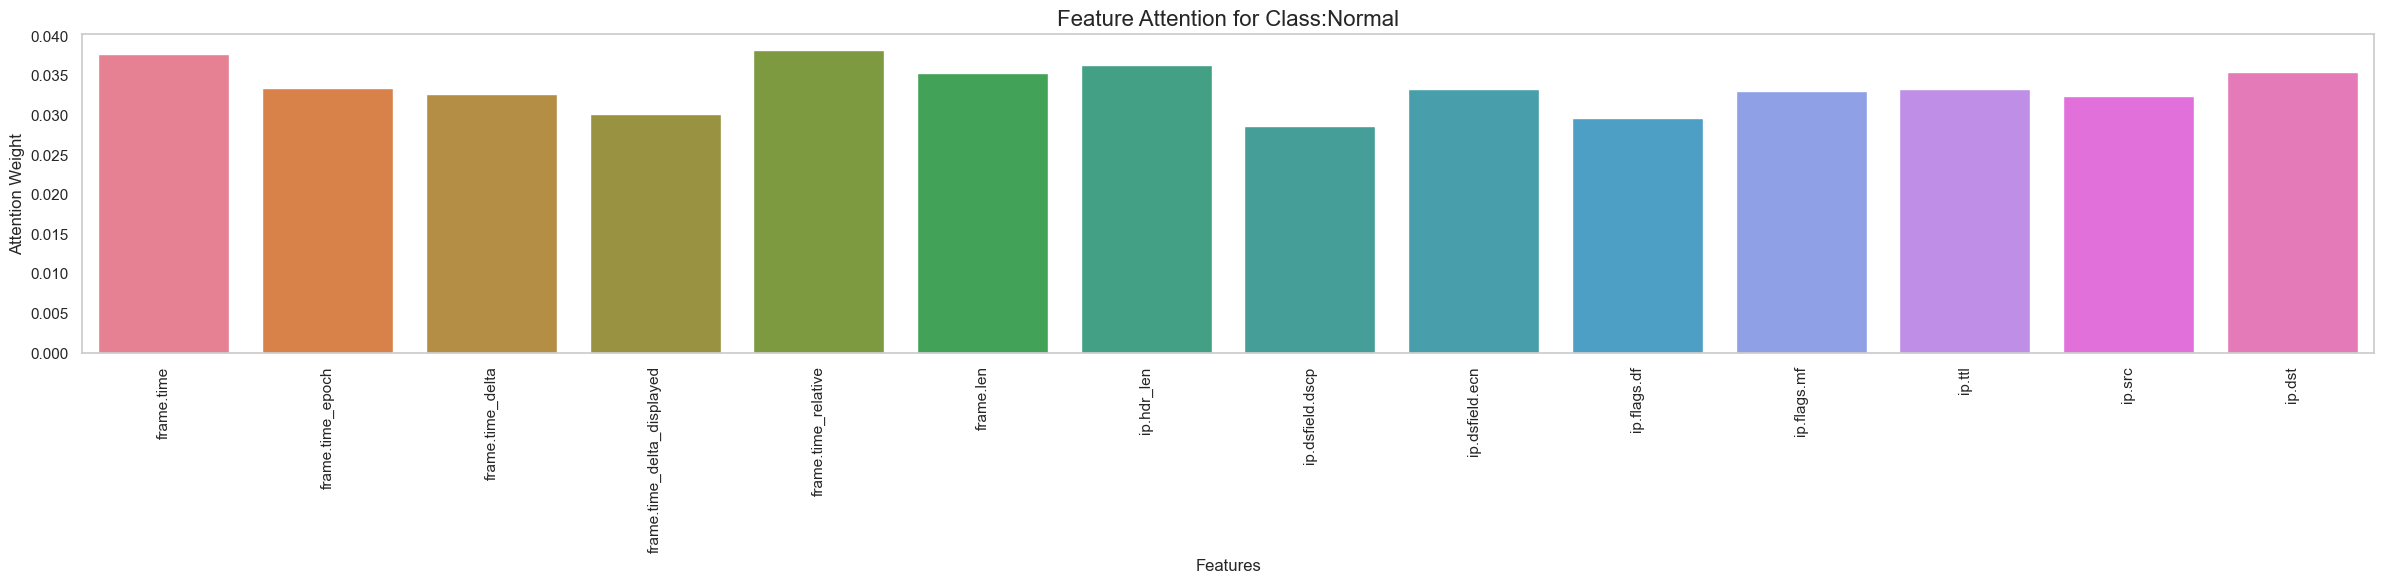

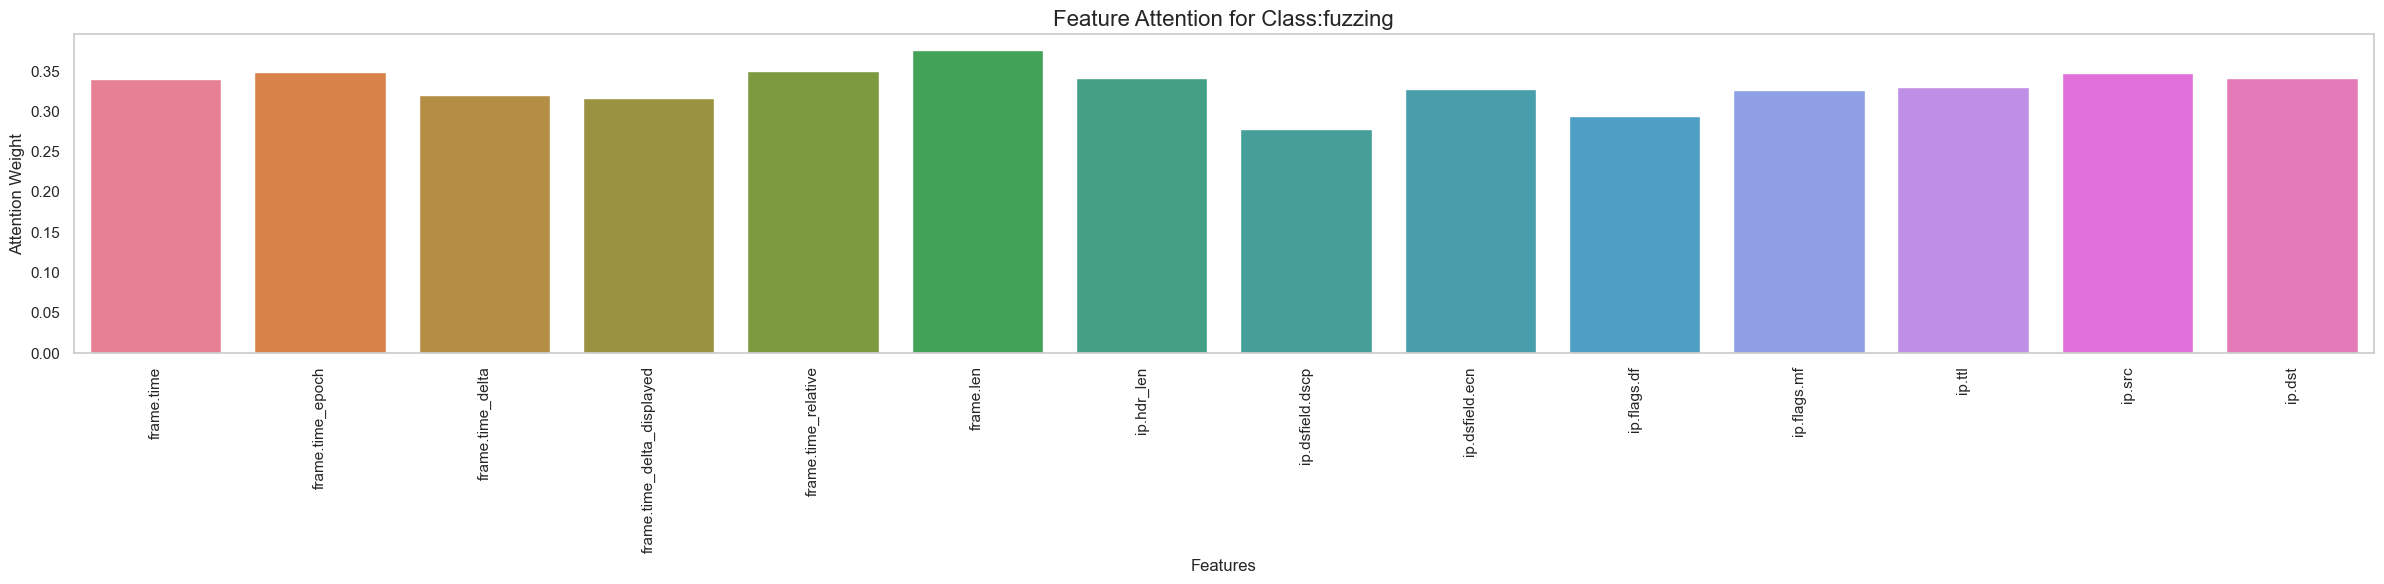

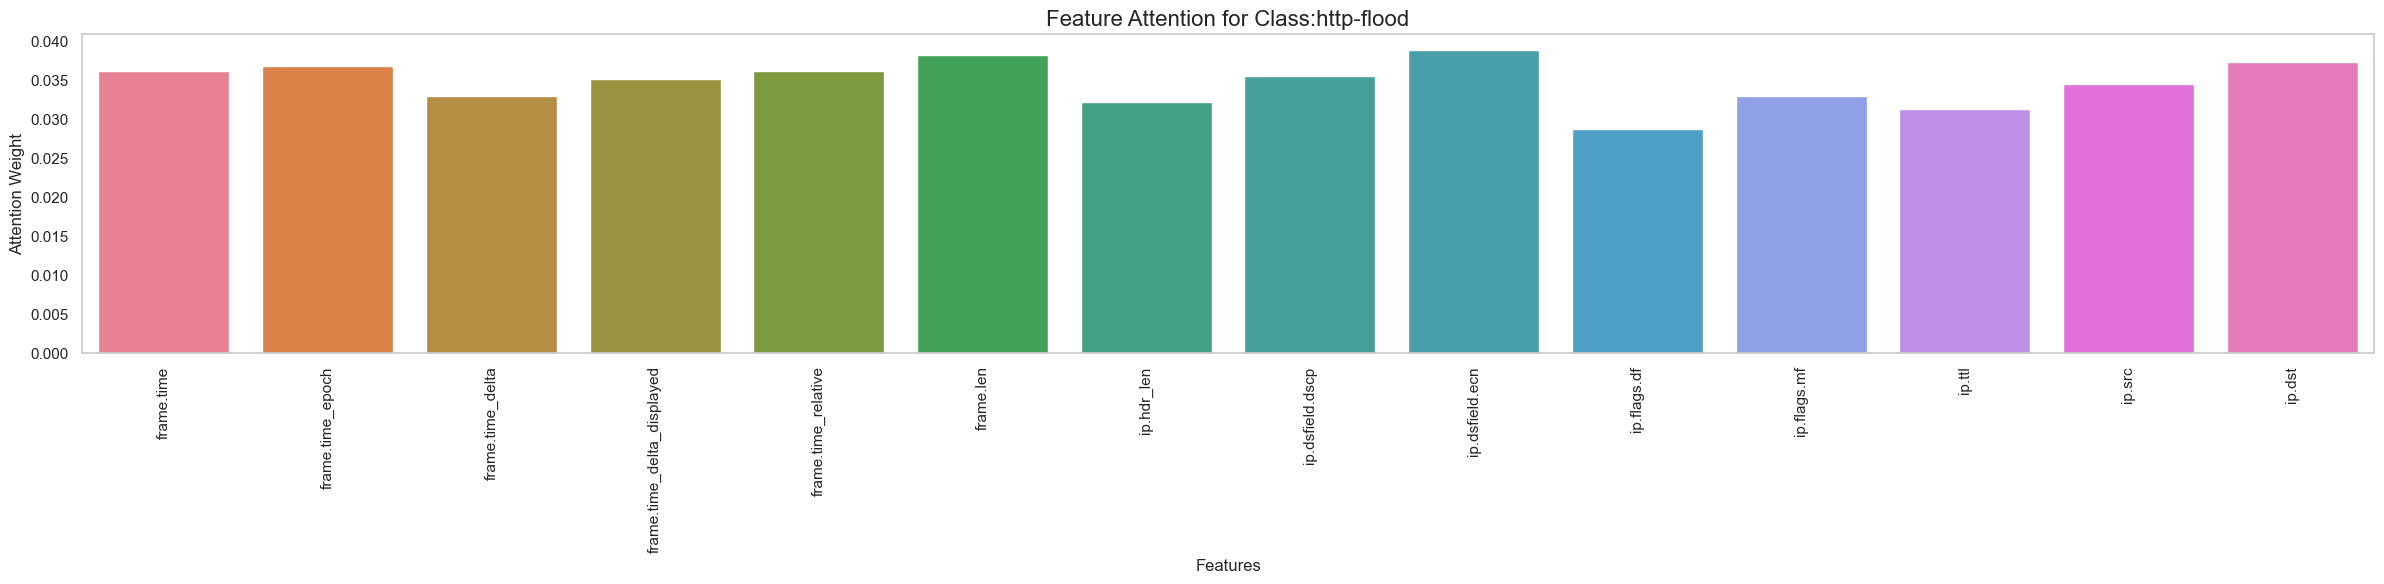

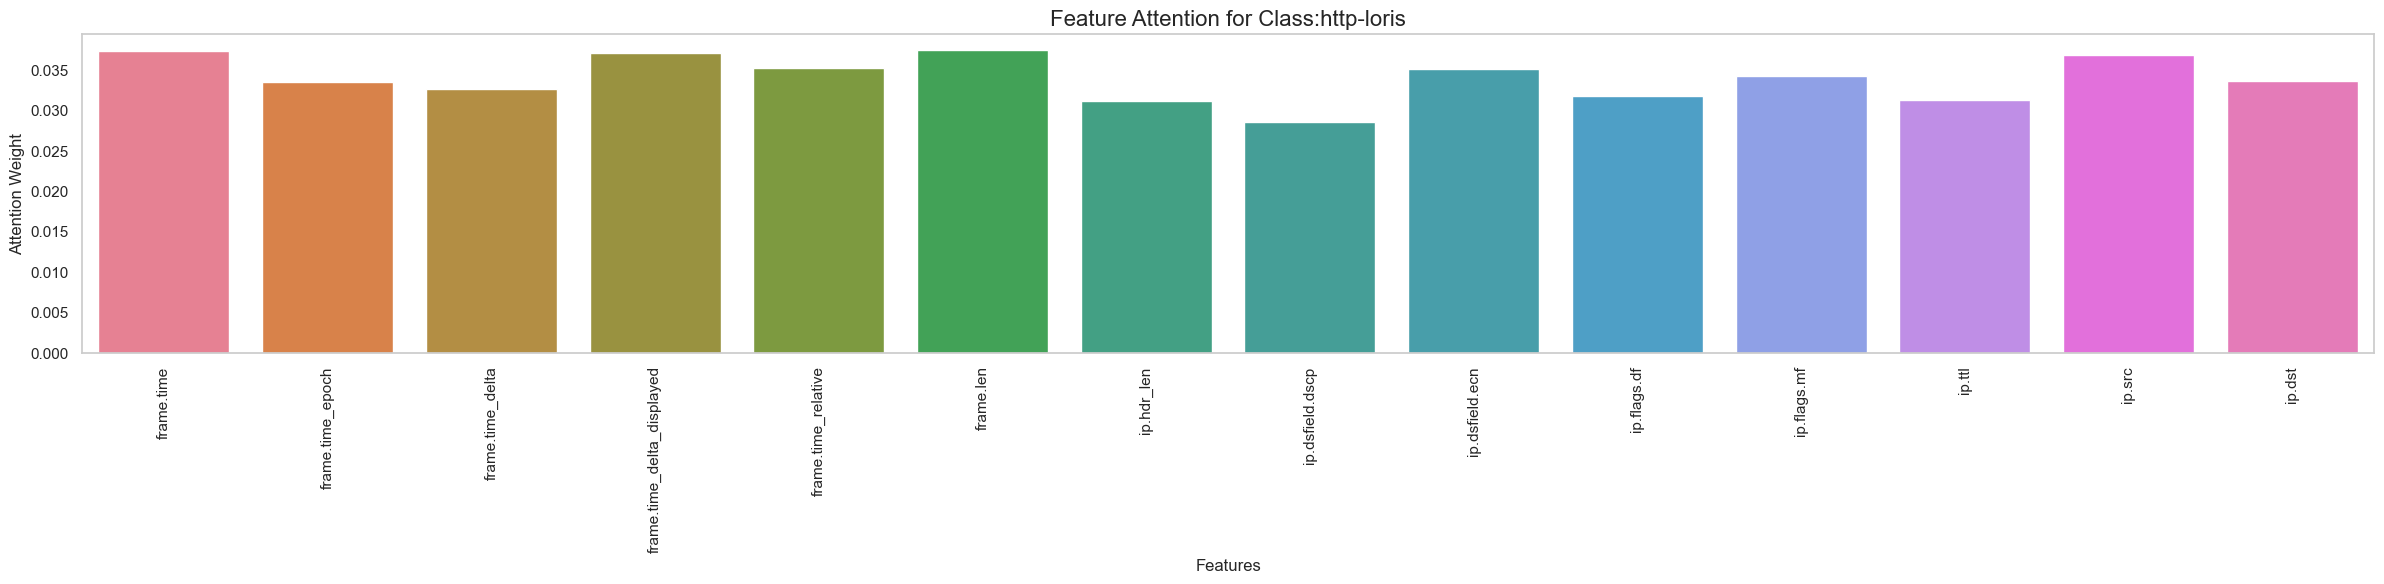

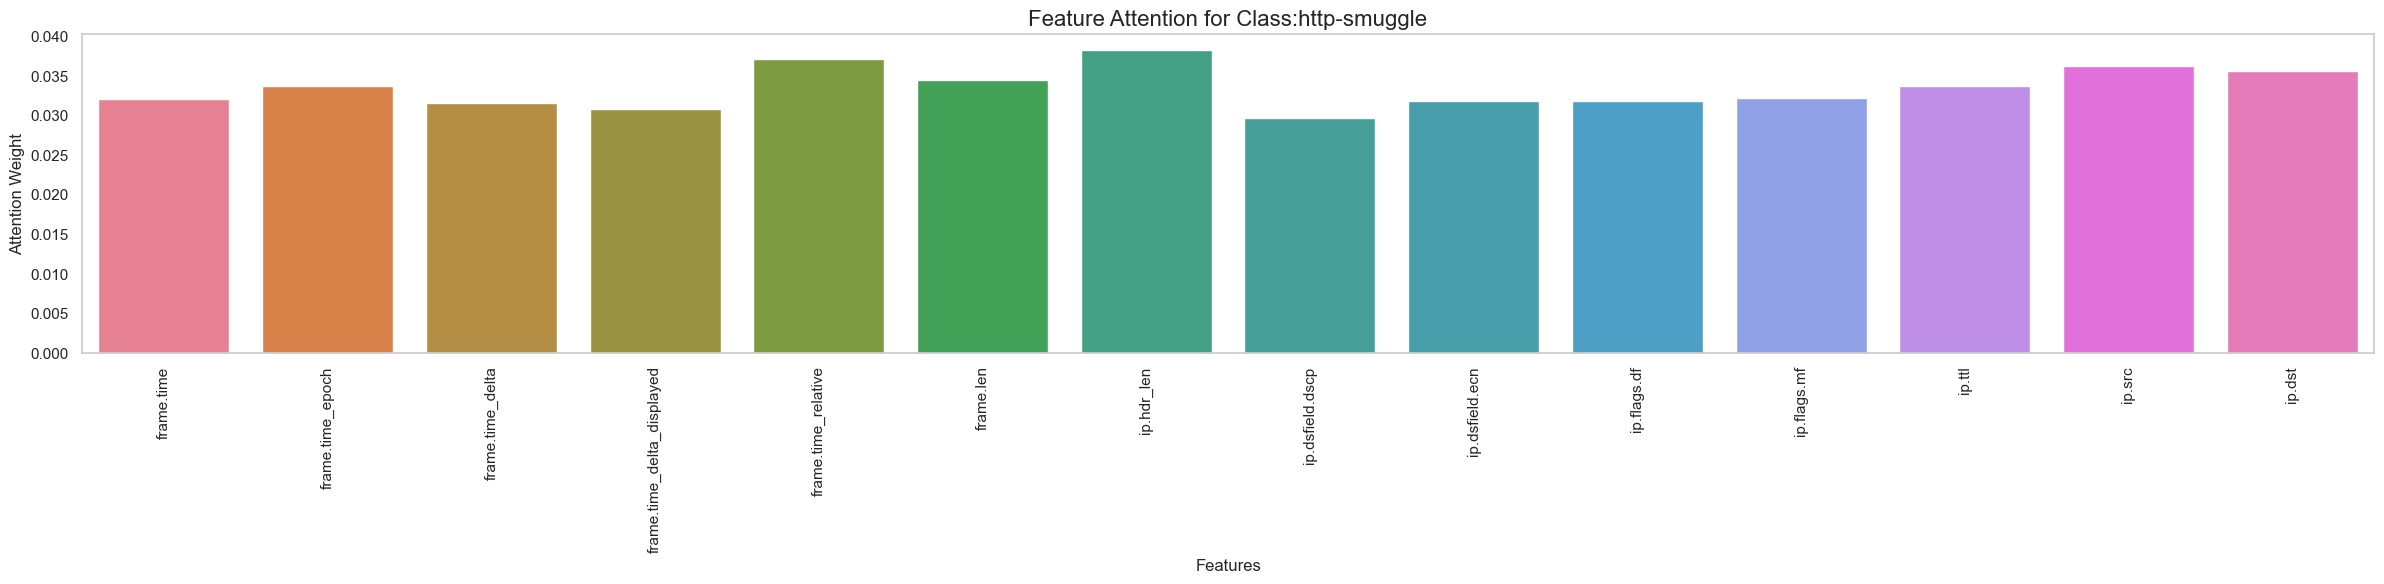

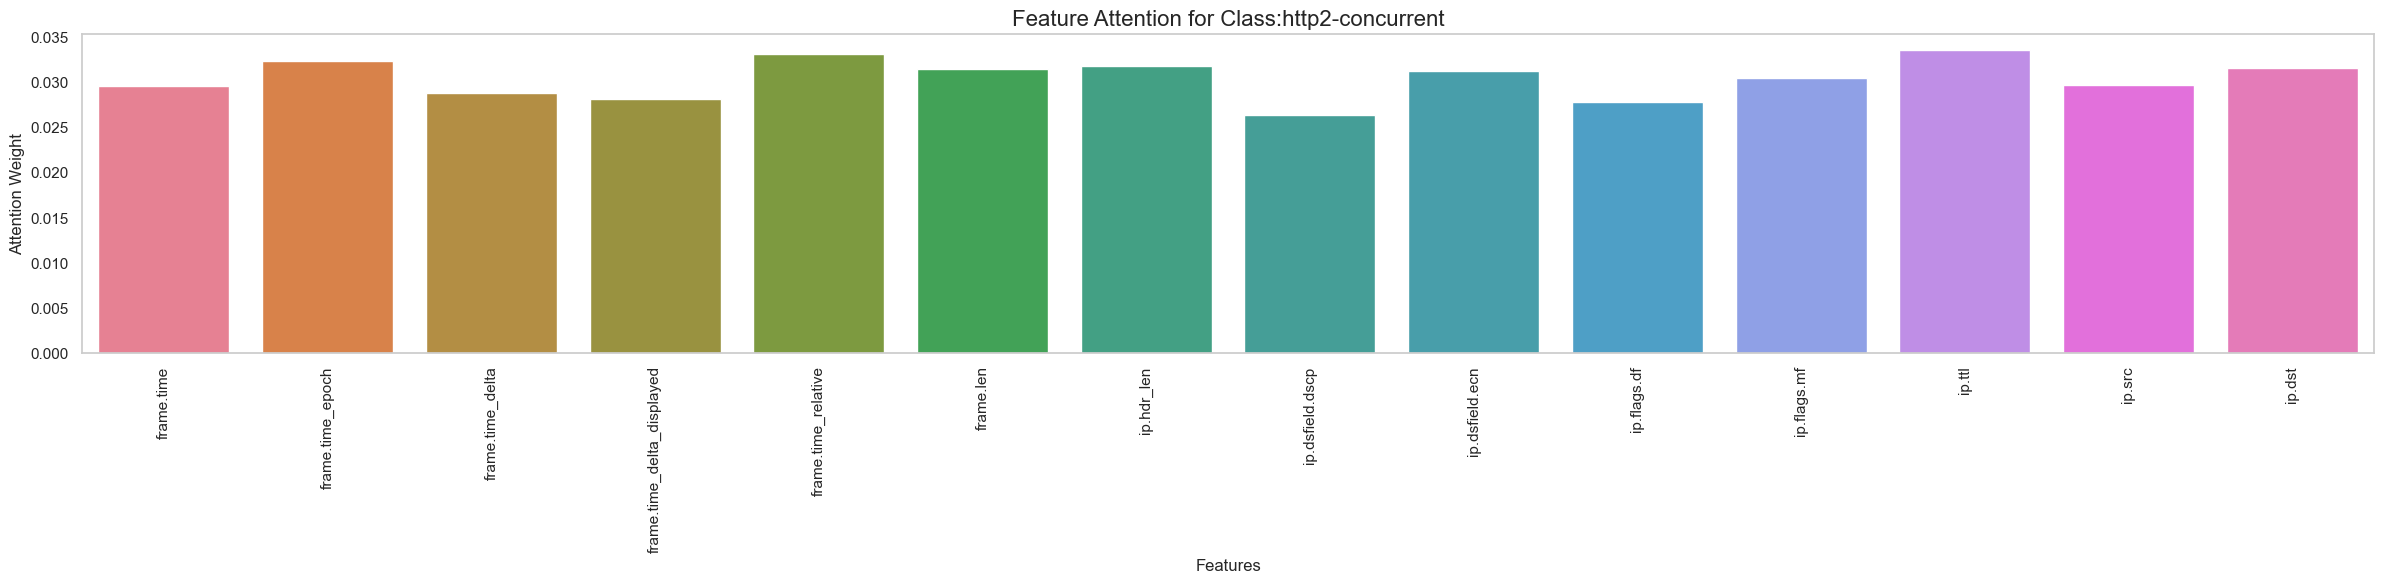

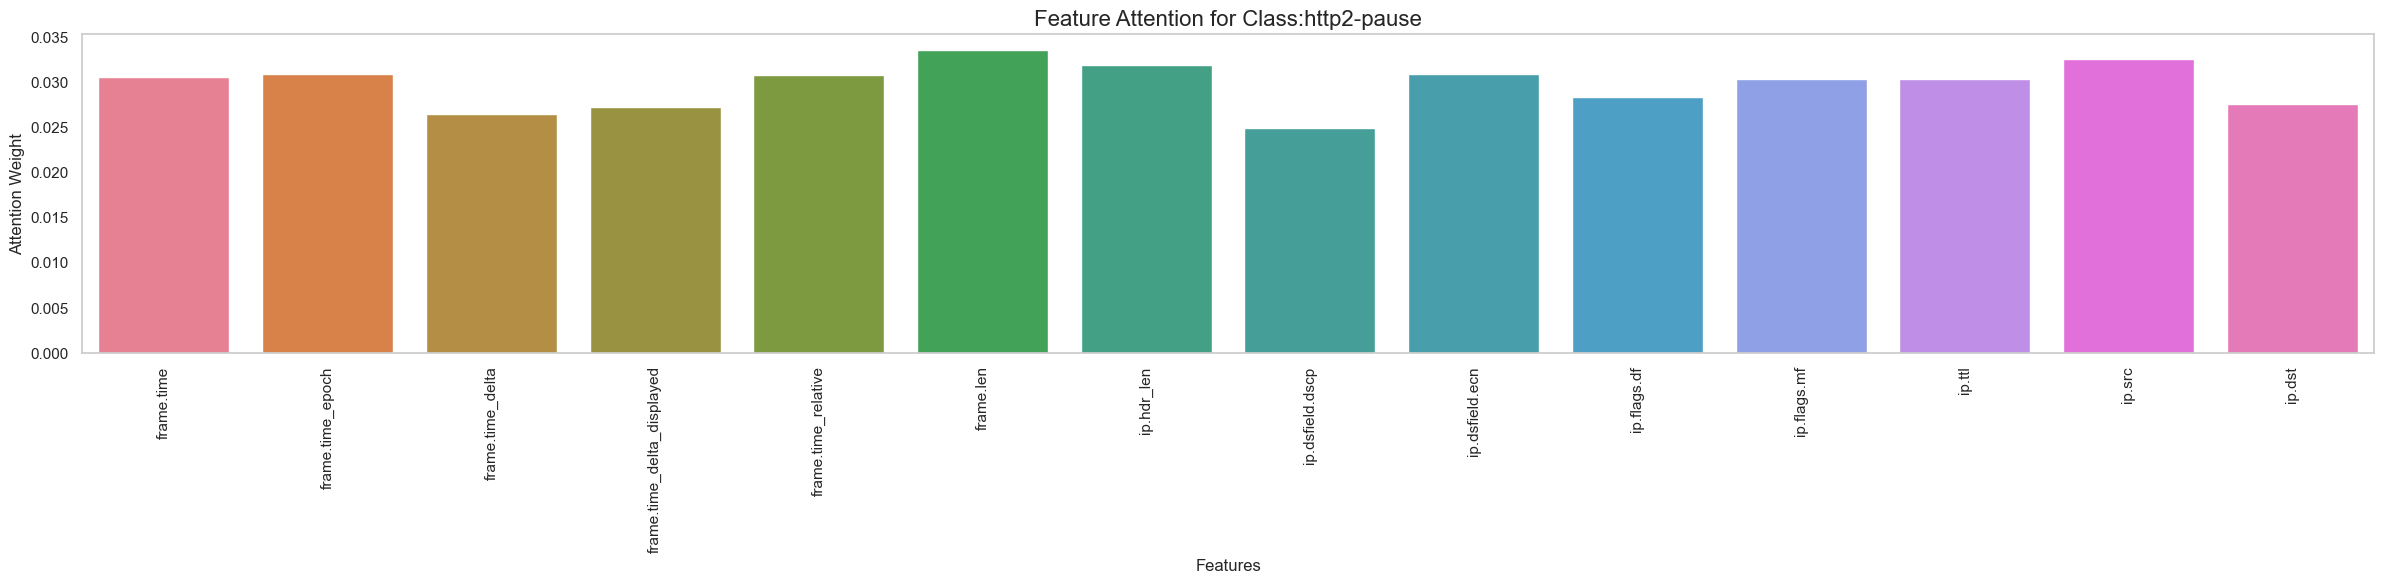

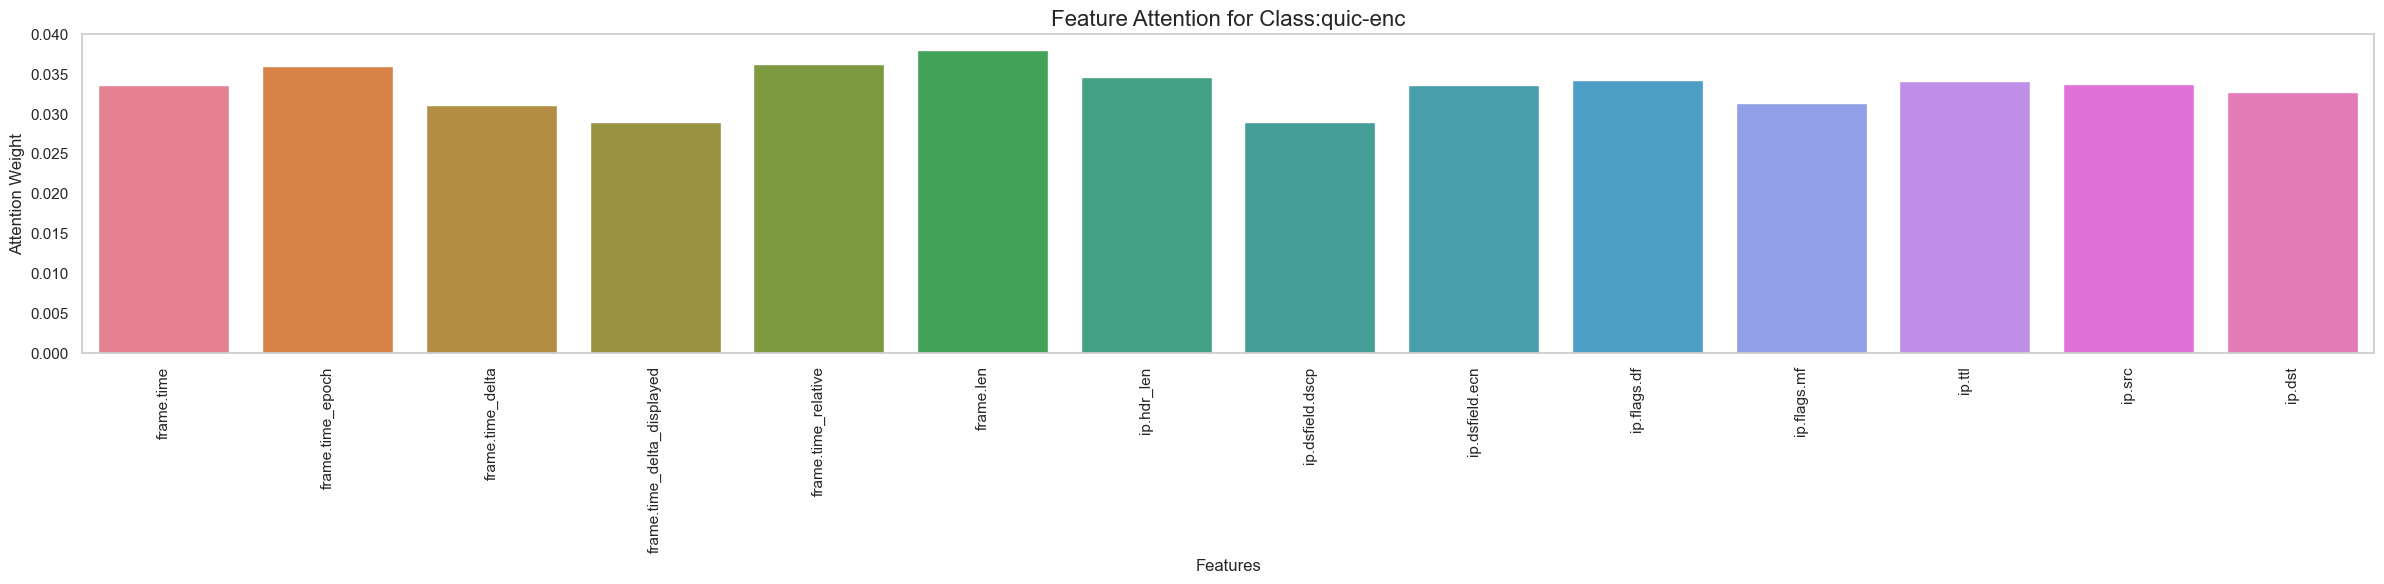

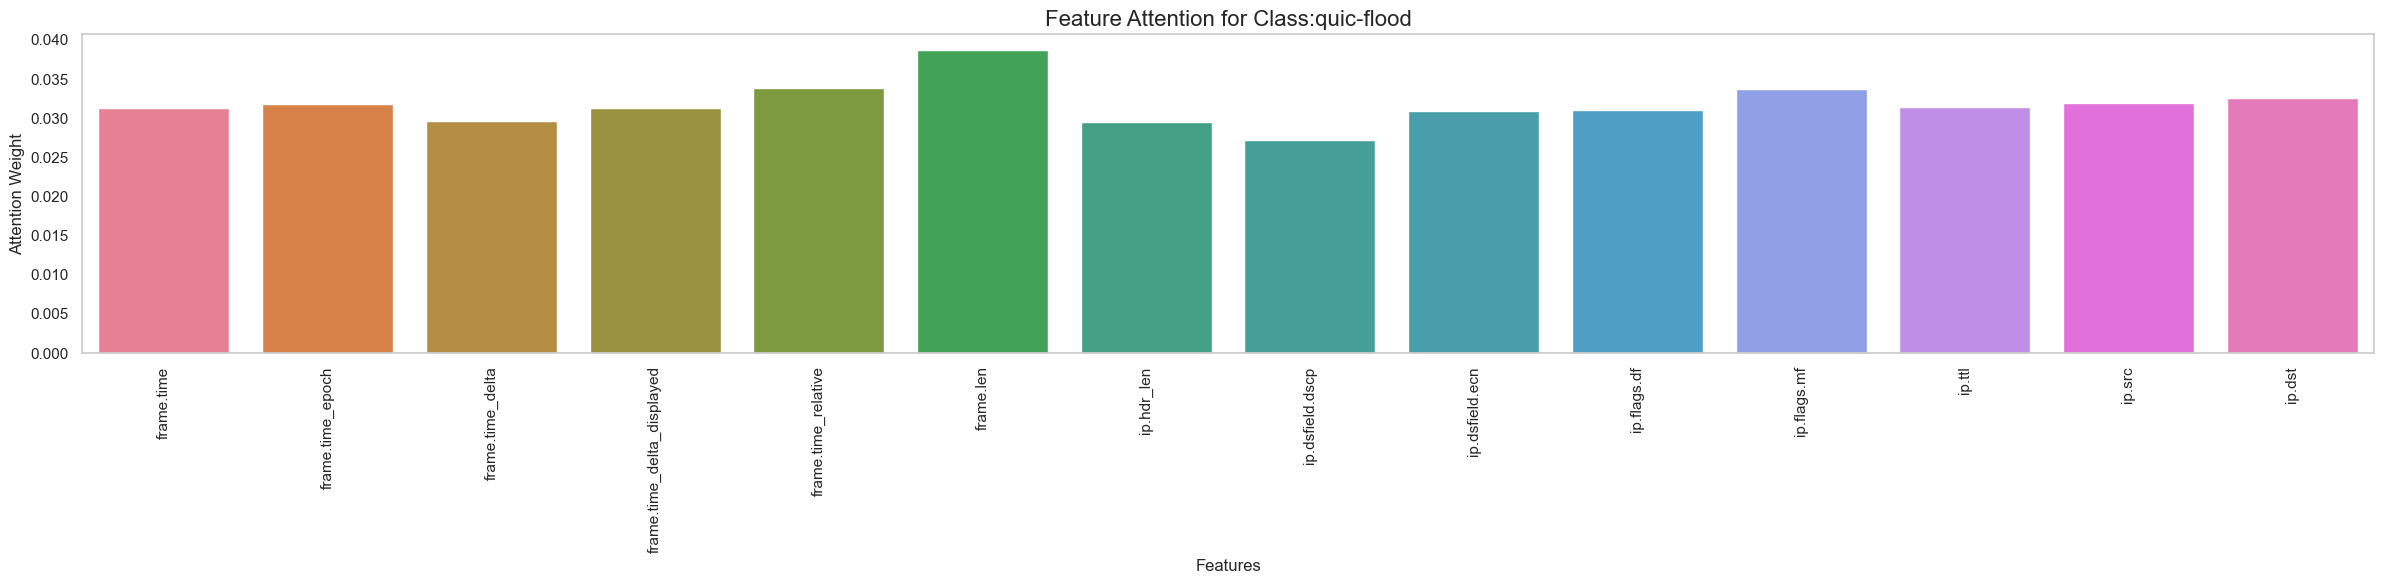

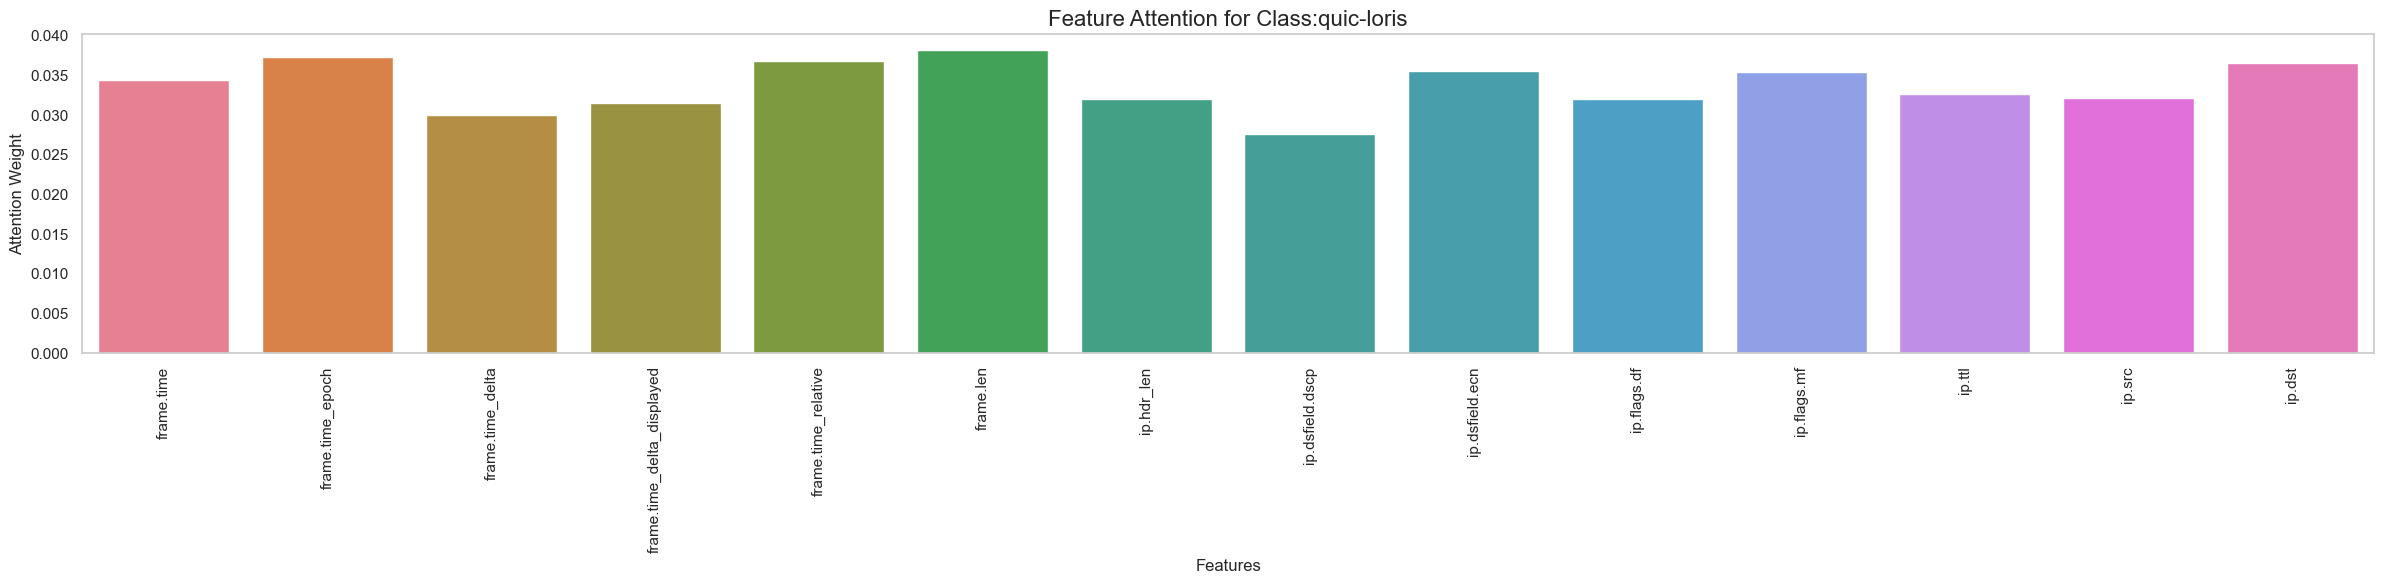

In [63]:
import numpy as np
import matplotlib.pyplot as plt


feature_names = ['frame.time', 'frame.time_epoch', 'frame.time_delta',
       'frame.time_delta_displayed', 'frame.time_relative', 'frame.len',
       'ip.hdr_len', 'ip.dsfield.dscp', 'ip.dsfield.ecn', 'ip.flags.df',
       'ip.flags.mf', 'ip.ttl', 'ip.src', 'ip.dst']

# Convert the feature names to indices
selected_feature_indices = [feature_names.index(name) for name in selected_feature_number.flatten()]

# Now you can slice the attention_weights_all using the indices

attention_weights_all = np.concatenate(attention_weights, axis=0)
attention_weights_all = attention_weights_all[:, selected_feature_indices]

y_true_all = np.concatenate(all_y_test, axis=0)
class_indices = np.argmax(y_true_all, axis=1)

# Compute average attention per class
num_classes = y_true_all.shape[1]
num_features = attention_weights_all.shape[1]

# Average attention per feature for each class
class_wise_attentions = np.zeros((num_classes, num_features))

for class_idx in range(num_classes):
    class_att_weights = attention_weights_all[class_indices == class_idx]
    class_wise_attentions[class_idx] = np.mean(class_att_weights, axis=0)

# Add your feature names

feature_names = [feature_names[i] for i in selected_feature_indices]

#  Add class names
class_names =  [
    'Normal','fuzzing', 'http-flood', 'http-loris', 'http-smuggle', 'http2-concurrent','http2-pause','quic-enc','quic-flood', 
      'quic-loris'
]
 
             
# Create a folder to save the plots (optional)
output_dir = "feature_importance_per_class_H23Q"
os.makedirs(output_dir, exist_ok=True)
import seaborn as sns

colors = sns.color_palette("husl", num_features)
sns.set_style("whitegrid")


for class_idx in range(num_classes):
    plt.figure(figsize=(12, 5))
    plt.bar(range(num_features), class_wise_attentions[class_idx], color=colors)
    plt.xticks(ticks=np.arange(num_features), labels=feature_names, rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Attention Weight')
    plt.title(f'Feature Attention for Class: {class_names[class_idx]}')
    plt.tight_layout()
    plt.grid(axis='y')
    plt.savefig(f"{output_dir}/{class_name}_feature_importance_multiclass_H23Q.png", dpi=1200)
    plt.show()
    


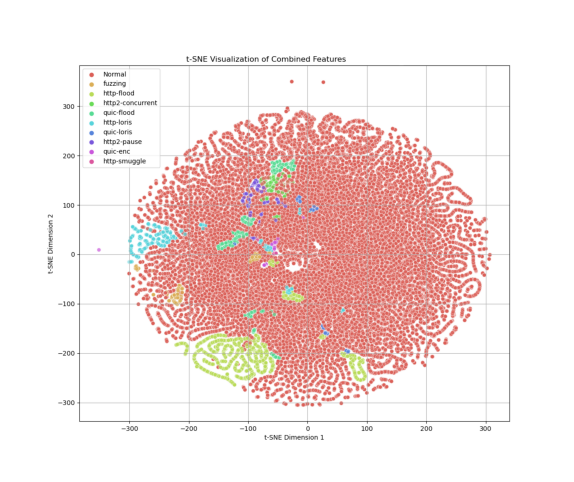

In [67]:
from sklearn.manifold import TSNE
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame()
tsne_df['Dim1'] = X_tsne[:, 0]
tsne_df['Dim2'] = X_tsne[:, 1]
tsne_df['Label'] = y

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='Label', palette='tab10', alpha=0.7)
plt.title('t-SNE Visualization of Combined Features(H23Q-Multiclass)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='lower left')
plt.tight_layout()
plt.savefig("peerj_revision1_H23Q-multiclass_tSNE.pdf",format="pdf")
plt.show()



